In [11]:
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil import parser
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectPercentile, f_regression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Lasso, Ridge, SGDRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, cross_validate, train_test_split


#printing:
########################
prntCols = True
# doCorrMatPlot = True
# doHistPlots = False
# doHistCompare = True
# doFeatImpPlot = False
# doPCAScreePlot = True
# doSimpleRgr = True
########################

########################
#preprocessing 
########################
startTotal=time.time()

flightPrices = pd.read_csv("/Users/dingleberry/Visual studio code workspace/DSC400s/DSC445/project/flight_prices_filteredFully.csv")

print(flightPrices.shape)

#drop redundant and needless columns
flightPrices.drop(columns=['isRefundable','isNonStop','isBasicEconomy','legId','fareBasisCode','baseFare', 'totalTravelDistance',
                           'travelDuration','seatsRemaining','elapsedDays','segmentsArrivalAirportCode',
                            'segmentsDepartureAirportCode','segmentsCabinCode','segmentsAirlineCode', 'segmentsDepartureTimeEpochSeconds',
                            'segmentsArrivalTimeEpochSeconds', 'segmentsArrivalTimeRaw'], inplace=True)

#testing subset
flightPrices = flightPrices.sample(frac=0.01, random_state=42)
print(flightPrices.shape)

#rename/remove segments names
flightPrices.columns = [col.replace('segments','')[0].lower() + col.replace('segments','')[1:] for col in flightPrices.columns]

flightPrices.rename(columns={'distance': 'distanceMiles'}, inplace=True)

###################################################
#feature engineering and transformation
###################################################

#departureHourLocal
def getLocalHour(s):
    dt = parser.isoparse(s) 
    return dt.hour

flightPrices['departureHourLocal'] = flightPrices['departureTimeRaw'].apply(getLocalHour)#.astype(int)

#duration (Hours)
flightPrices['travelDurationHours'] = flightPrices['durationInSeconds']/3600

#days in advance
flightPrices['flightDate'] = pd.to_datetime(flightPrices['flightDate'])
flightPrices['searchDate'] = pd.to_datetime(flightPrices['searchDate'])
flightPrices['daysInAdvance'] = (flightPrices['flightDate'] - flightPrices['searchDate']).dt.days

#day of the week
flightPrices['dayOfWeek'] = flightPrices['flightDate'].dt.dayofweek

#day of year
flightPrices['dayOfYear'] = flightPrices['flightDate'].dt.dayofyear

#isWeekned
flightPrices['isWeekend'] = flightPrices['flightDate'].dt.dayofweek >=5

#searchIsWeekend
flightPrices['searchIsWeekend'] = flightPrices['searchDate'].dt.dayofweek >=5

#pricePerMile
flightPrices['pricePerMile'] = flightPrices['totalFare']/flightPrices['distanceMiles']

#distPerHour(mph)
flightPrices['distPerHour(mph)'] = flightPrices['distanceMiles']/flightPrices['travelDurationHours']

#route
flightPrices['route'] = flightPrices['startingAirport'] + '-' + flightPrices['destinationAirport']

#isHoliday
#Holidays: April 17(easter), May 5, May 8(mothers), May 30(memorial), June 19, July 4, September 5, September 11
holidays_2022 = ['2022-04-17','2022-05-05','2022-05-08','2022-05-30', '2022-06-19', '2022-07-04','2022-09-05','2022-09-11' ]
holidays_2022 = pd.to_datetime(holidays_2022)
flightPrices['isHoliday'] = flightPrices['flightDate'].isin(holidays_2022)

#departurePeriod
def getPeriod(h):
    if 6 <= h < 12:
        return "morning"
    elif 12 <= h < 18:
        return "afternoon"
    elif 18 <= h < 24:
        return "evening"
    else:
        return "night"

flightPrices['departurePeriod'] = flightPrices['departureHourLocal'].apply(getPeriod)

#remove bc redundant. 
flightPrices['flightDate'] = flightPrices['flightDate'].astype(int)
flightPrices['searchDate'] = flightPrices['searchDate'].astype(int)

#drop redundant features
flightPrices.drop(columns=['departureTimeRaw','durationInSeconds', 'flightDate', 'searchDate', 'startingAirport', 'destinationAirport', 'route', 'equipmentDescription','departurePeriod'],inplace=True)
#flightPrices.drop(columns=[ 'distanceMiles', 'dayOfYear','travelDurationHours','isWeekend', 'searchIsWeekend', ], inplace=True)
print(flightPrices.shape)
cols = flightPrices.columns
if prntCols: print(cols) 

#sort dimensions 
target = ['totalFare']
numericFeatures = ['dayOfYear','departureHourLocal', 'dayOfWeek', 'daysInAdvance', 'pricePerMile', 'distPerHour(mph)' ] 
#catFeatures = ['airlineName']
binaryFeatures = [ 'isHoliday']

(3569724, 27)
(35697, 10)
(35697, 13)
Index(['totalFare', 'airlineName', 'distanceMiles', 'departureHourLocal',
       'travelDurationHours', 'daysInAdvance', 'dayOfWeek', 'dayOfYear',
       'isWeekend', 'searchIsWeekend', 'pricePerMile', 'distPerHour(mph)',
       'isHoliday'],
      dtype='object')


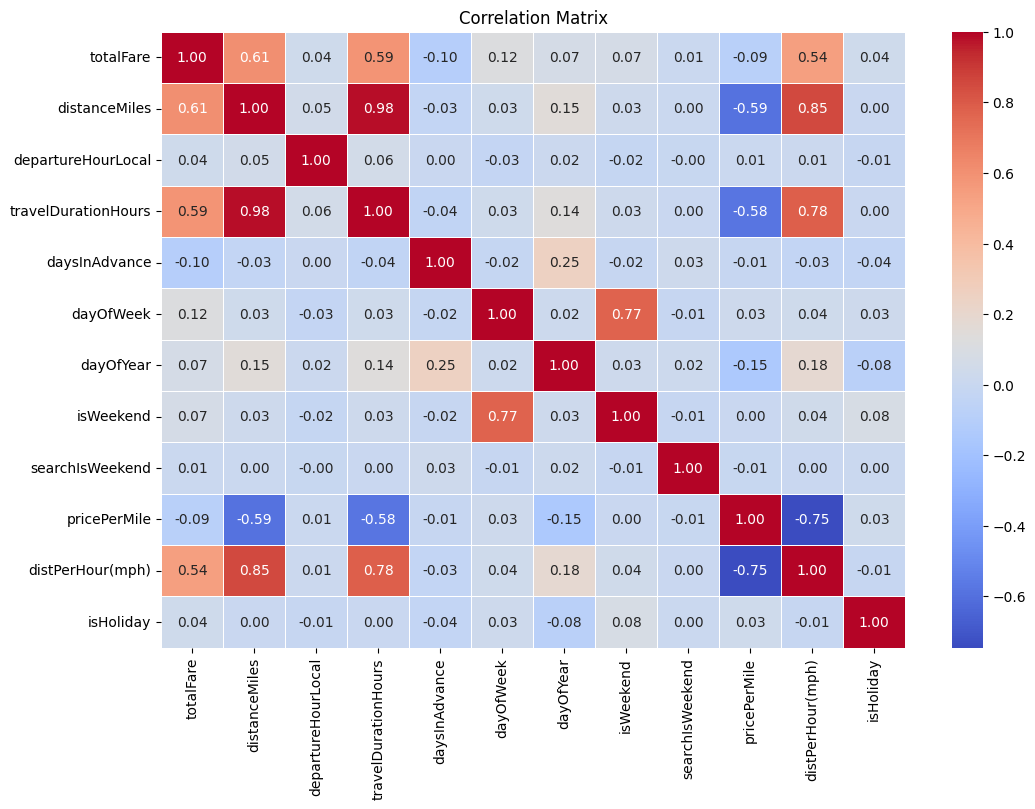

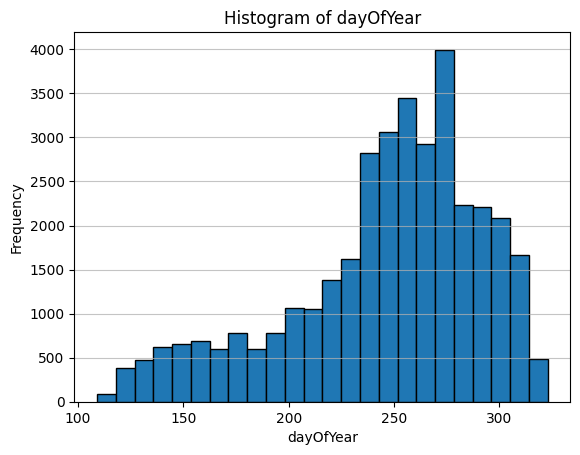

visual #0 done


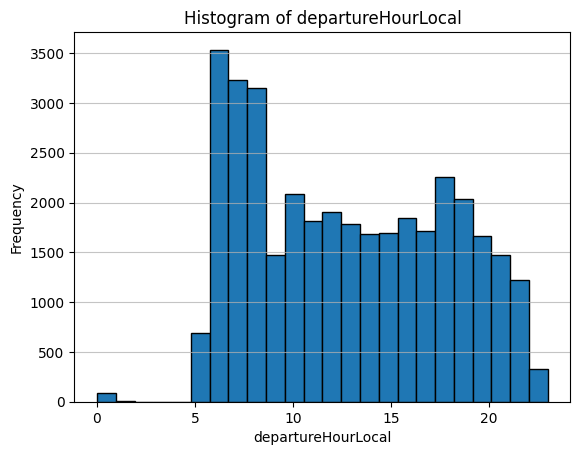

visual #1 done


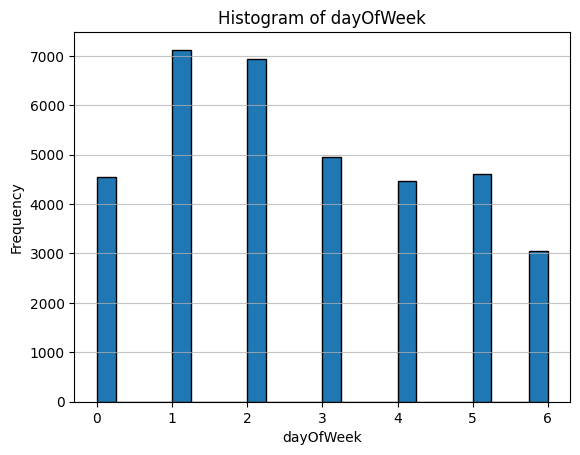

visual #2 done


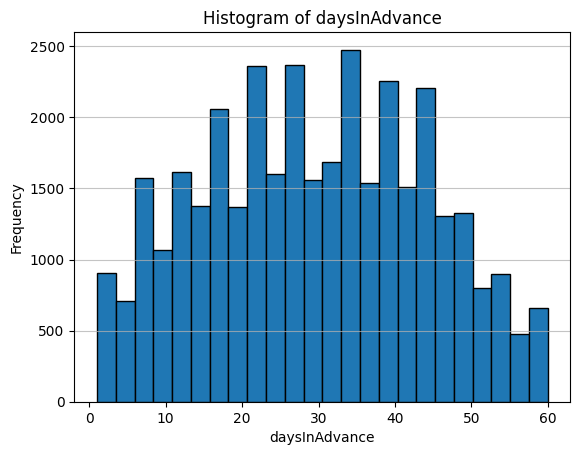

visual #3 done


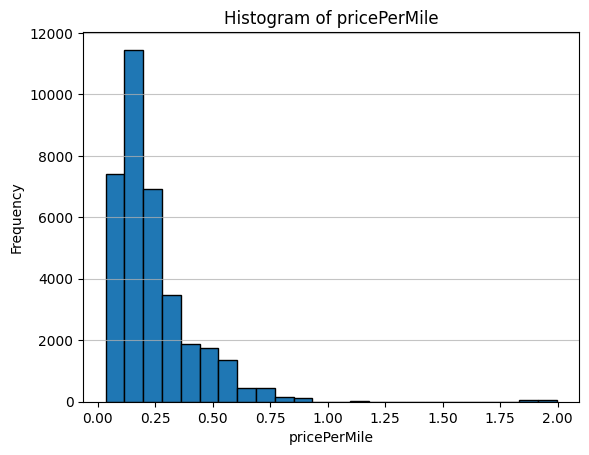

visual #4 done


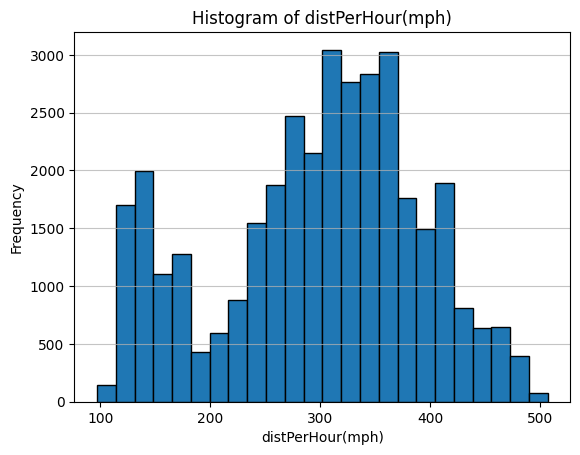

visual #5 done


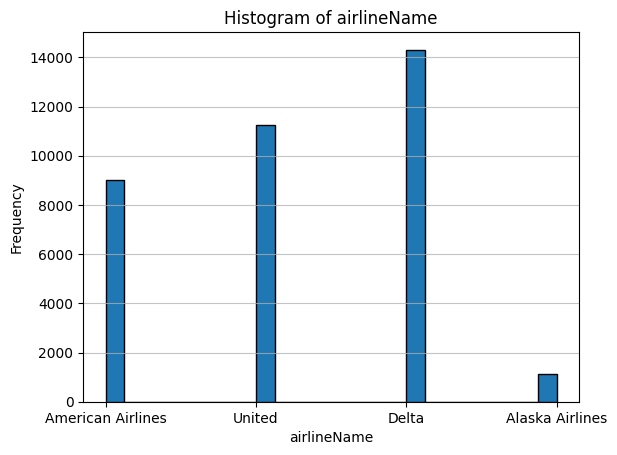

visual #6 done


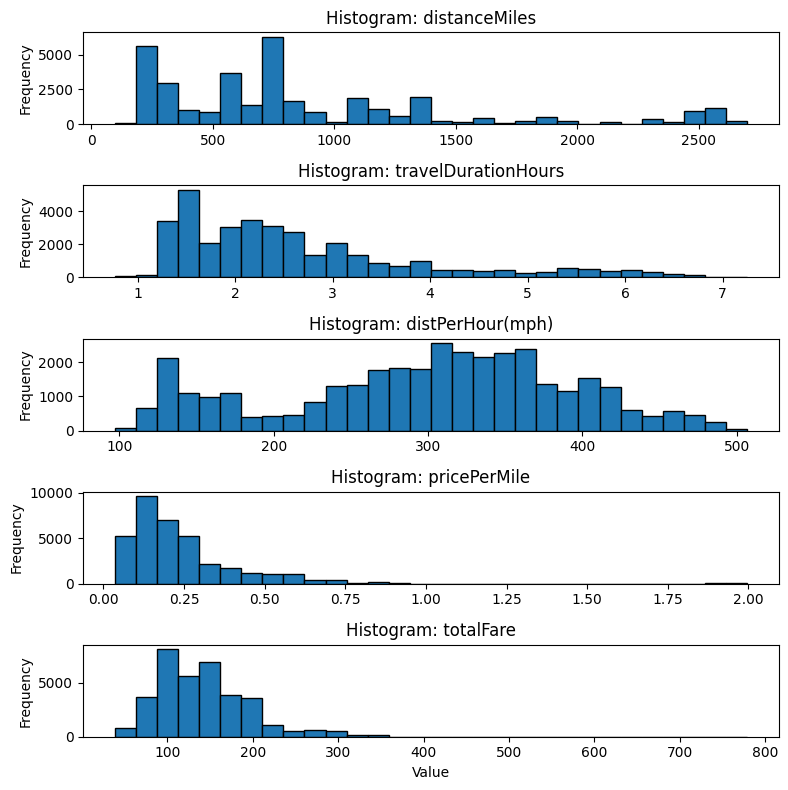

In [12]:

corrMat = flightPrices.corr(numeric_only=True)


plt.figure(figsize=(12, 8))
sns.heatmap(corrMat, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


count = 0
for col in numericFeatures:
    plt.hist(flightPrices[col].dropna(), bins=24, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
    print(f"visual #{count} done")
    count+=1
for col in catFeatures:
    plt.hist(flightPrices[col].dropna(), bins=24, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
    print(f"visual #{count} done")
    count+=1

features = ['distanceMiles', 'travelDurationHours', 'distPerHour(mph)', 'pricePerMile', 'totalFare']

fig, axes = plt.subplots(len(features), 1, figsize=(8, 8))

for i, feat in enumerate(features):
    axes[i].hist(flightPrices[feat].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(f"Histogram: {feat}")
    axes[i].set_ylabel("Frequency")

axes[-1].set_xlabel("Value")
plt.tight_layout()
plt.show()


In [8]:
#one hot encode categorical features
flightPrices = pd.get_dummies(flightPrices, columns=catFeatures, drop_first=True)
print(flightPrices.shape)
flightPrices = flightPrices.dropna()
print(flightPrices.shape)

x = flightPrices.drop(columns=['totalFare'])
y = flightPrices['totalFare']

binaryFeatures = [col for col in x.columns if col not in numericFeatures]
#scale here?
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

scaler = StandardScaler()

#fit on training numeric features only
X_train_scaled_numeric = scaler.fit_transform(X_train[numericFeatures])
X_test_scaled_numeric  = scaler.transform(X_test[numericFeatures])

X_train_scaled_numeric = pd.DataFrame(X_train_scaled_numeric, columns=numericFeatures, index=X_train.index)
X_test_scaled_numeric = pd.DataFrame(X_test_scaled_numeric, columns=numericFeatures, index=X_test.index)

X_train_scaled = pd.concat([X_train_scaled_numeric, X_train[binaryFeatures]], axis=1)
X_test_scaled  = pd.concat([X_test_scaled_numeric, X_test[binaryFeatures]], axis=1)

(35697, 10)
(35540, 10)


In [23]:
flightPrices['totalFare'].describe()

count    35540.000000
mean       141.494610
std         56.064691
min         38.610000
25%        101.600000
50%        133.600000
75%        169.350000
max        778.600000
Name: totalFare, dtype: float64

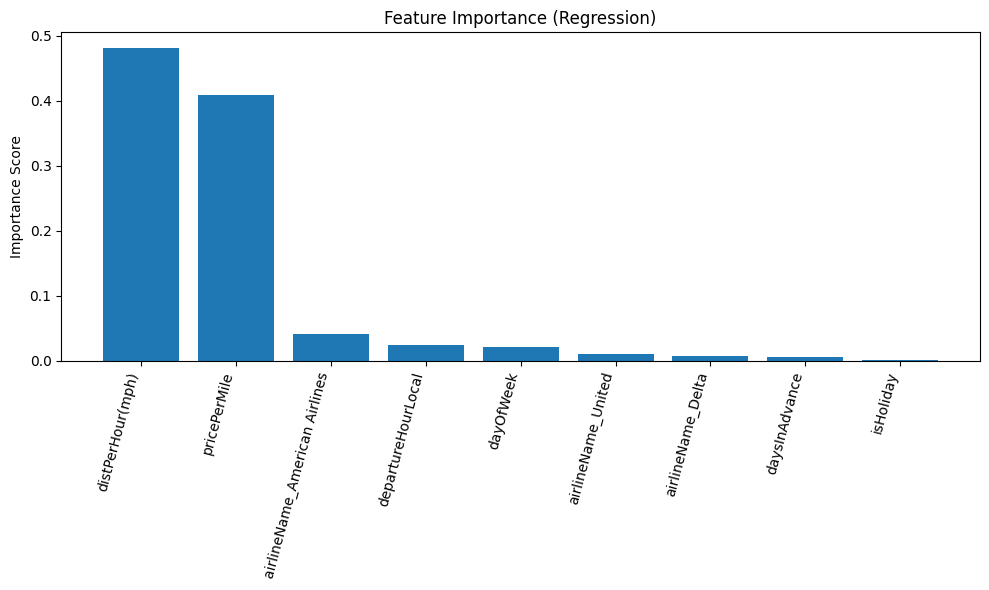

Number of components to retain 95% variance: 6


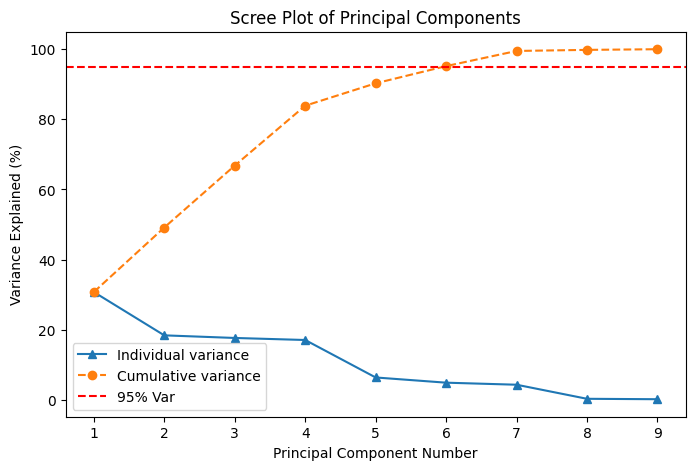

RMSE for training data: 5.16624


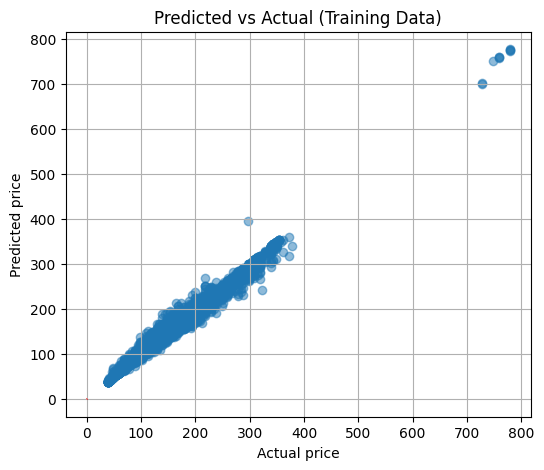

In [9]:
basicRFrgr = RandomForestRegressor()
basicRFrgr.fit(X_train_scaled, y_train)

importances = basicRFrgr.feature_importances_
featureNames = X_train.columns

indices = np.argsort(importances)[::-1]
sortedFeatures = featureNames[indices]
sortedImportances = importances[indices]
plt.figure(figsize=(10, 6))
plt.bar(sortedFeatures, sortedImportances)
plt.xticks(rotation=75, ha='right')
plt.title("Feature Importance (Regression)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


pca = PCA()
X_trainPCA = pca.fit(X_train_scaled).transform(X_train_scaled)
varPercentage = pca.explained_variance_ratio_*100
cumVar = np.cumsum(varPercentage)

r = np.argmax(cumVar >= 95) + 1 
print(f"Number of components to retain 95% variance: {r}")
plt.figure(figsize=(8,5))
plt.plot(range(1, len(varPercentage) + 1), varPercentage, marker='^', label='Individual variance')
plt.plot(range(1, len(cumVar) + 1), cumVar, marker='o', linestyle='--', label='Cumulative variance')
plt.axhline(95, color='r', linestyle='--', label='95% Var')
plt.xlabel('Principal Component Number')
plt.ylabel('Variance Explained (%)')
plt.title('Scree Plot of Principal Components')
plt.legend()
plt.show()

rgr = RandomForestRegressor()
rgr.fit(X_train_scaled, y_train)

trainPred = rgr.predict(X_train_scaled)

rmseTrain = np.sqrt(mean_squared_error(y_train, trainPred))
print(f"RMSE for training data: {rmseTrain:.5f}")

plt.figure(figsize=(6, 5))
plt.scatter(y_train, trainPred, alpha=0.5)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Predicted vs Actual (Training Data)")
plt.plot([0, 1], [0, 1], 'r--') 
plt.grid(True)
plt.show()

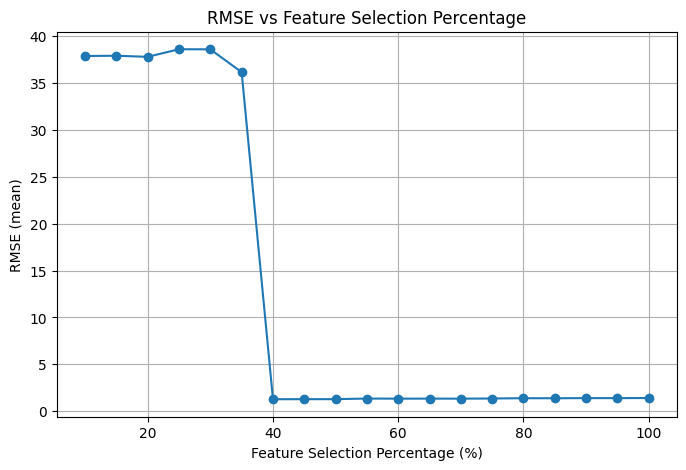


Overall Best RMSE: 1.2779
Best feature selection percentage: 40%
random forest:

RMSE on test data after feature selection (40%): 1.11886
features selected (6 total): ['distanceMiles', 'travelDurationHours', 'dayOfWeek', 'daysInAdvance', 'pricePerMile', 'distPerHour(mph)']



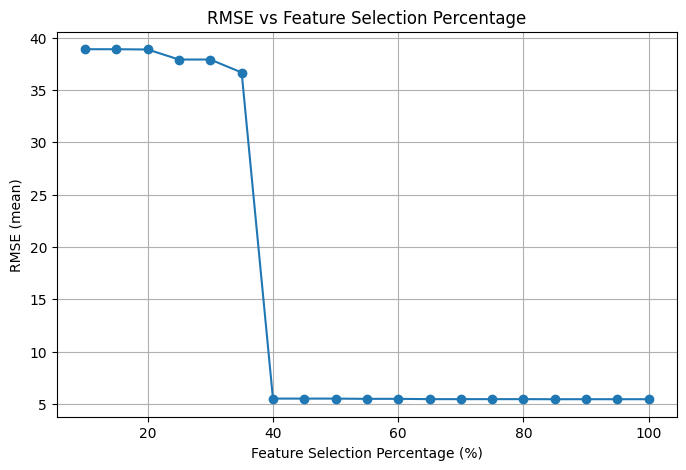


Overall Best RMSE: 5.4612
Best feature selection percentage: 95%
gradient boosting:

RMSE on test data after feature selection (40%): 5.56610
features selected (13 total): ['distanceMiles', 'dayOfYear', 'departureHourLocal', 'travelDurationHours', 'dayOfWeek', 'daysInAdvance', 'pricePerMile', 'distPerHour(mph)', 'isWeekend', 'searchIsWeekend', 'isHoliday', 'airlineName_American Airlines', 'airlineName_United']



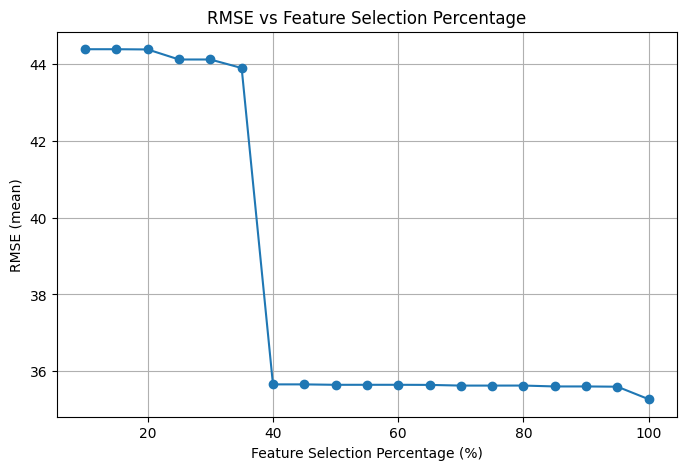


Overall Best RMSE: 35.2695
Best feature selection percentage: 100%
ridge:

RMSE on test data after feature selection (40%): 34.85147
features selected (14 total): ['distanceMiles', 'dayOfYear', 'departureHourLocal', 'travelDurationHours', 'dayOfWeek', 'daysInAdvance', 'pricePerMile', 'distPerHour(mph)', 'isWeekend', 'searchIsWeekend', 'isHoliday', 'airlineName_American Airlines', 'airlineName_Delta', 'airlineName_United']



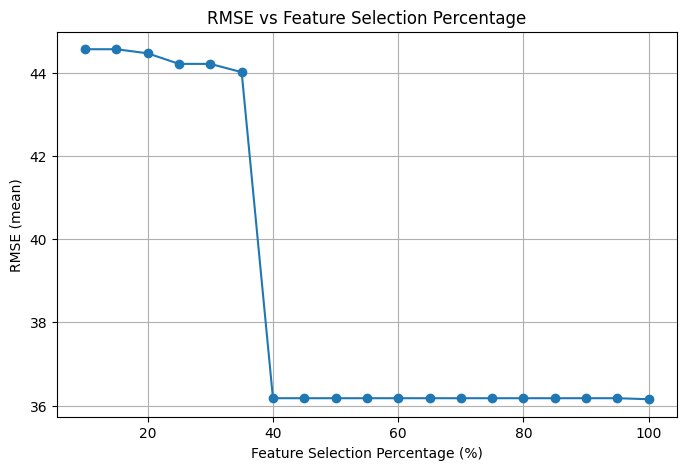


Overall Best RMSE: 36.1531
Best feature selection percentage: 100%
lasso

RMSE on test data after feature selection (40%): 35.94794
features selected (14 total): ['distanceMiles', 'dayOfYear', 'departureHourLocal', 'travelDurationHours', 'dayOfWeek', 'daysInAdvance', 'pricePerMile', 'distPerHour(mph)', 'isWeekend', 'searchIsWeekend', 'isHoliday', 'airlineName_American Airlines', 'airlineName_Delta', 'airlineName_United']



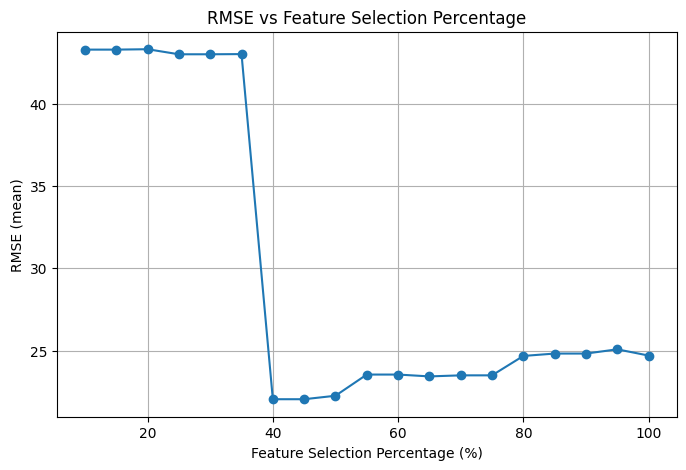


Overall Best RMSE: 22.0464
Best feature selection percentage: 40%
SVM:

RMSE on test data after feature selection (40%): 21.10192
features selected (6 total): ['distanceMiles', 'travelDurationHours', 'dayOfWeek', 'daysInAdvance', 'pricePerMile', 'distPerHour(mph)']



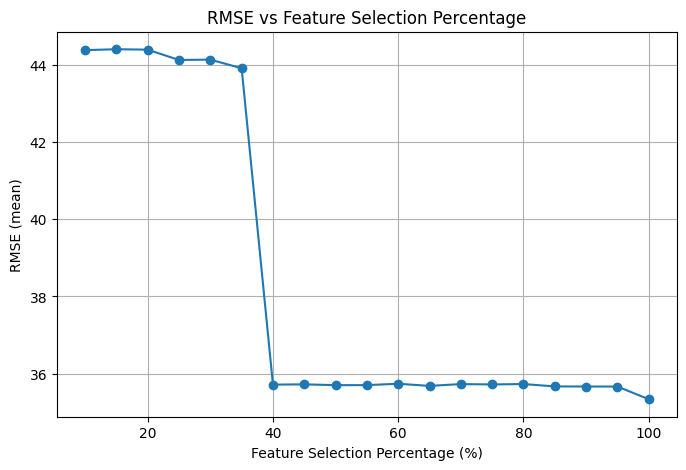


Overall Best RMSE: 35.3330
Best feature selection percentage: 100%
SVM:

RMSE on test data after feature selection (40%): 35.43060
features selected (14 total): ['distanceMiles', 'dayOfYear', 'departureHourLocal', 'travelDurationHours', 'dayOfWeek', 'daysInAdvance', 'pricePerMile', 'distPerHour(mph)', 'isWeekend', 'searchIsWeekend', 'isHoliday', 'airlineName_American Airlines', 'airlineName_Delta', 'airlineName_United']



/Users/dingleberry/Visual studio code workspace/sklearn-env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/dingleberry/Visual studio code workspace/sklearn-env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/dingleberry/Visual studio code workspace/sklearn-env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/dingleberry/Visual studio code workspace/sklearn-env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Sto

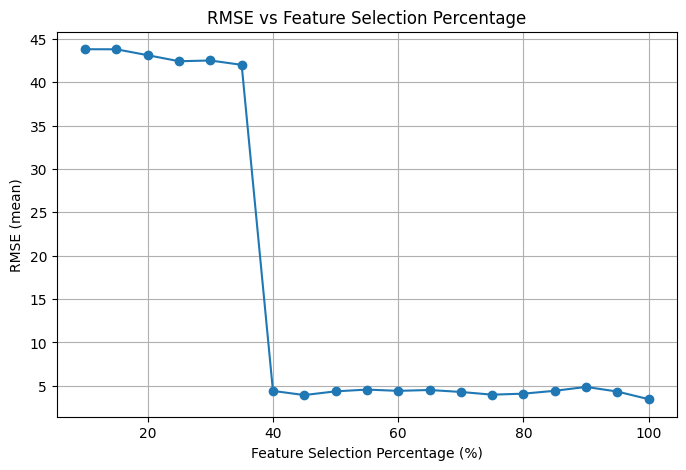


Overall Best RMSE: 3.4603
Best feature selection percentage: 100%
SVM:

RMSE on test data after feature selection (40%): 2.52291
features selected (14 total): ['distanceMiles', 'dayOfYear', 'departureHourLocal', 'travelDurationHours', 'dayOfWeek', 'daysInAdvance', 'pricePerMile', 'distPerHour(mph)', 'isWeekend', 'searchIsWeekend', 'isHoliday', 'airlineName_American Airlines', 'airlineName_Delta', 'airlineName_United']



/Users/dingleberry/Visual studio code workspace/sklearn-env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [19]:
#Parameters:
#X = predictor variables; y = target variable, model = regression model, k = kfold splits
#returns best feature selection percentage and list of selected features
def selectFeatures(X, y, model, k=5, doPrints=False):
    features = X.columns.tolist()
    cv = KFold(n_splits=k, shuffle=True, random_state=33)

    rmseFeaturesPerc = {}
    #rangess from 10% to 100% in increments of 5%
    for p in range(10, 101, 5):
        fs = SelectPercentile(score_func=f_regression, percentile=p)
        xFs = fs.fit_transform(X, y)
        rmse = -cross_val_score(model, xFs, y, scoring='neg_root_mean_squared_error', cv=cv)
        boolSelected = fs.get_support()

        selectedFeatures = [x for i,x in enumerate(features) if boolSelected[i]]

        rmseFeaturesPerc[p] = (rmse.mean(), selectedFeatures)
        if doPrints:
            print(f"\n--- Feature Selection: Top {p}% ---")
            print(f"RMSE (mean): {rmse.mean():.4f}")
            print(f"number of features selected: {len(selectedFeatures)} (top {p}%)")
            print(f"Selected features: {selectedFeatures.tolist()}")

    minRMSE = min([v[0] for v in rmseFeaturesPerc.values()])
    bestPerc = [k for k,v in rmseFeaturesPerc.items() if v[0]==minRMSE][0]

    plt.figure(figsize=(8, 5))
    plt.plot(list(rmseFeaturesPerc.keys()), [v[0] for v in rmseFeaturesPerc.values()], marker='o')
    plt.title("RMSE vs Feature Selection Percentage")
    plt.xlabel("Feature Selection Percentage (%)")
    plt.ylabel("RMSE (mean)")
    plt.grid(True)
    plt.show()
    print(f"\nOverall Best RMSE: {minRMSE:.4f}")
    print(f"Best feature selection percentage: {bestPerc}%")
    
    return bestPerc, rmseFeaturesPerc[bestPerc][1] 

####################
#random forest
####################
rfRgr = RandomForestRegressor()
bestRfPerc, selectedFeatures = selectFeatures(X_train_scaled, y_train, rfRgr, k=5)
X_trainFS = X_train_scaled[selectedFeatures]
X_testFS = X_test_scaled[selectedFeatures]
rfRgr.fit(X_trainFS, y_train)
testPredFS = rfRgr.predict(X_testFS)
rmseTestFS = np.sqrt(mean_squared_error(y_test, testPredFS))
print(40*"=")
print("random forest:")
print(40*"=")
print(f"\nRMSE on test data after feature selection ({bestRfPerc}%): {rmseTestFS:.5f}")
print(f"features selected ({len(selectedFeatures)} total): {selectedFeatures}")
print()
####################
#gradient booting
####################
gbRgr = GradientBoostingRegressor()
bestGbPerc, selectedFeatures = selectFeatures(X_train_scaled, y_train, gbRgr, k=5)
X_trainFS = X_train_scaled[selectedFeatures]
X_testFS = X_test_scaled[selectedFeatures]
gbRgr.fit(X_trainFS, y_train)
testPredFS = gbRgr.predict(X_testFS)
rmseTestFS = np.sqrt(mean_squared_error(y_test, testPredFS))
print(40*"=")
print("gradient boosting:")
print(40*"=")
print(f"\nRMSE on test data after feature selection ({bestRfPerc}%): {rmseTestFS:.5f}")
print(f"features selected ({len(selectedFeatures)} total): {selectedFeatures}")
print()
####################
#ridge 
####################
ridgeRgr = Ridge()
bestRidgePerc, selectedFeatures = selectFeatures(X_train_scaled, y_train, ridgeRgr, k=5)
X_trainFS = X_train_scaled[selectedFeatures]
X_testFS = X_test_scaled[selectedFeatures]
ridgeRgr.fit(X_trainFS, y_train)
testPredFS = ridgeRgr.predict(X_testFS)
rmseTestFS = np.sqrt(mean_squared_error(y_test, testPredFS))
print(40*"=")
print("ridge:")
print(40*"=")
print(f"\nRMSE on test data after feature selection ({bestRfPerc}%): {rmseTestFS:.5f}")
print(f"features selected ({len(selectedFeatures)} total): {selectedFeatures}")
print()
####################
#lasso 
####################
lassoRgr = Lasso()
bestLassoPerc, selectedFeatures = selectFeatures(X_train_scaled, y_train, lassoRgr, k=5)
X_trainFS = X_train_scaled[selectedFeatures]
X_testFS = X_test_scaled[selectedFeatures]
lassoRgr.fit(X_trainFS, y_train)
testPredFS = lassoRgr.predict(X_testFS)
rmseTestFS = np.sqrt(mean_squared_error(y_test, testPredFS))
print(40*"=")
print("lasso")
print(40*"=")
print(f"\nRMSE on test data after feature selection ({bestRfPerc}%): {rmseTestFS:.5f}")
print(f"features selected ({len(selectedFeatures)} total): {selectedFeatures}")
print()
####################
#SVR
####################
svmRgr = SVR()
bestSvmPerc, selectedFeatures = selectFeatures(X_train_scaled, y_train, svmRgr, k=5)
X_trainFS = X_train_scaled[selectedFeatures]
X_testFS = X_test_scaled[selectedFeatures]
svmRgr.fit(X_trainFS, y_train)
testPredFS = svmRgr.predict(X_testFS)
rmseTestFS = np.sqrt(mean_squared_error(y_test, testPredFS))
print(40*"=")
print("SVM:")
print(40*"=")
print(f"\nRMSE on test data after feature selection ({bestRfPerc}%): {rmseTestFS:.5f}")
print(f"features selected ({len(selectedFeatures)} total): {selectedFeatures}")
print()
####################
#SDGregressor
####################
sdgRgr = SGDRegressor()
bestSgdPerc, selectedFeatures = selectFeatures(X_train_scaled, y_train, sdgRgr, k=5)
X_trainFS = X_train_scaled[selectedFeatures]
X_testFS = X_test_scaled[selectedFeatures]
sdgRgr.fit(X_trainFS, y_train)
testPredFS = sdgRgr.predict(X_testFS)
rmseTestFS = np.sqrt(mean_squared_error(y_test, testPredFS))
print(40*"=")
print("SVM:")
print(40*"=")
print(f"\nRMSE on test data after feature selection ({bestRfPerc}%): {rmseTestFS:.5f}")
print(f"features selected ({len(selectedFeatures)} total): {selectedFeatures}")
print()
####################
#neural network MLPRegressor
####################
mlpRgr = MLPRegressor()
bestMlpPerc, selectedFeatures = selectFeatures(X_train_scaled, y_train, mlpRgr, k=5)
X_trainFS = X_train_scaled[selectedFeatures]
X_testFS = X_test_scaled[selectedFeatures]
mlpRgr.fit(X_trainFS, y_train)
testPredFS = mlpRgr.predict(X_testFS)
rmseTestFS = np.sqrt(mean_squared_error(y_test, testPredFS))
print(40*"=")
print("SVM:")
print(40*"=")
print(f"\nRMSE on test data after feature selection ({bestRfPerc}%): {rmseTestFS:.5f}")
print(f"features selected ({len(selectedFeatures)} total): {selectedFeatures}")
print()


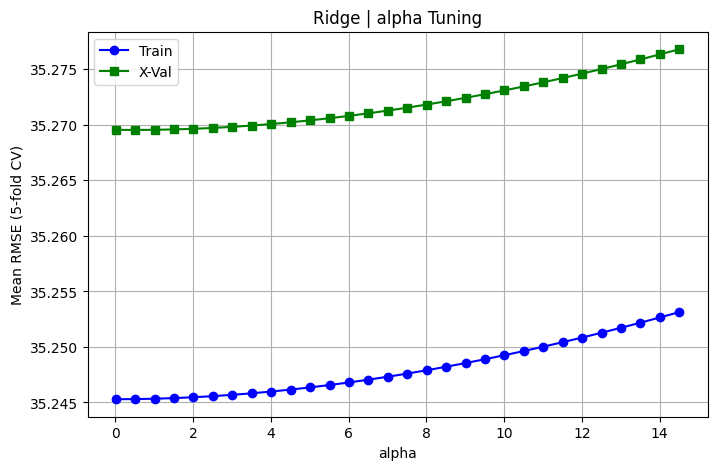


Best alpha: 0.51 with Validation RMSE: 35.2695


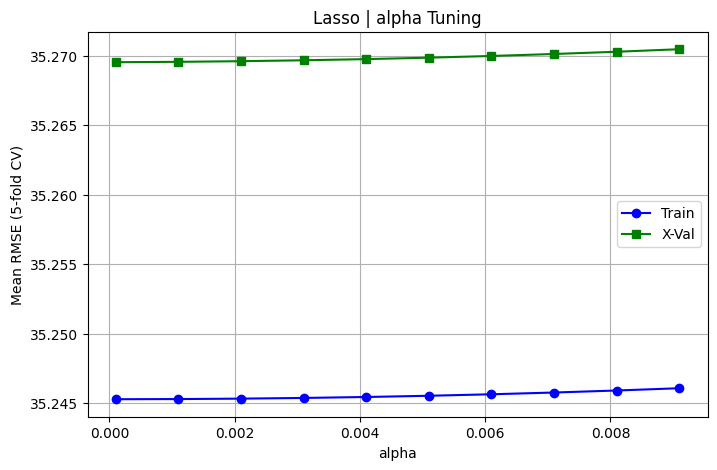


Best alpha: 0.0001 with Validation RMSE: 35.2695


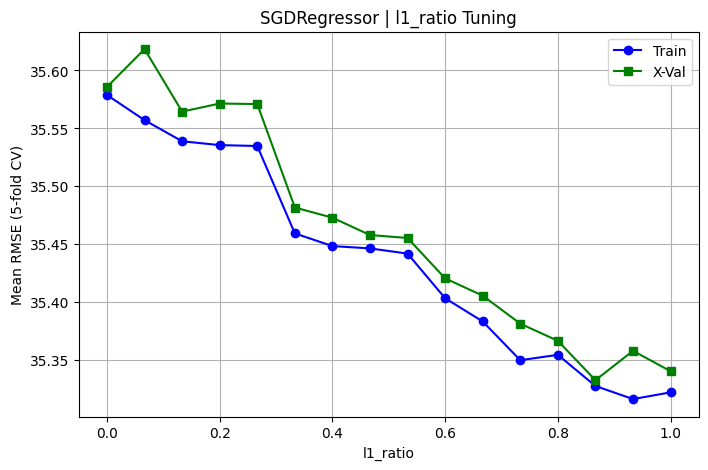


Best l1_ratio: 0.8666666666666667 with Validation RMSE: 35.3322

Ridge Regression Test RMSE (alpha=0.51): 34.85309
Lasso Regression Test RMSE (alpha=0.0001): 34.85044


/Users/dingleberry/Visual studio code workspace/sklearn-env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.092e+07, tolerance: 6.710e+03
  model = cd_fast.enet_coordinate_descent(


In [24]:
#Parameters:
#X = predictor variables; y = target variable, model = regression model, paramName = name of parameter to tune
#paramValues = list of parameter values to test, k = kfold splits
#returns best parameter value
def paraTuning(X, y, model, paramName, paramValues, k=5, isScaled=True, doPrints=False):
    cv = KFold(n_splits=k, shuffle=True, random_state=33)
    #rmseAlpha = {}
    train_rmse = np.zeros(len(paramValues))
    val_rmse = np.zeros(len(paramValues))

    for i, p in enumerate (paramValues):
        # model.set_params(alpha=p)
        # rmse = -cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=cv)
        # rmseAlpha[p] = rmse.mean()
        # if doPrints:
        #     print(f"Alpha: {p}, RMSE (mean): {rmse.mean():.4f}")
            
        model.set_params(**{paramName:p})
        
        fold_train_rmse = []
        fold_val_rmse = []
        #manual k-fold cv
        for trainIdx, valIdx in cv.split(X):
            if hasattr(X, 'iloc'):
                xTrainCV, xValCV = X.iloc[trainIdx], X.iloc[valIdx]
            else:
                xTrainCV, xValCV = X[trainIdx], X[valIdx]

            if hasattr(y, 'iloc'):
                yTrainCV, yValCV = y.iloc[trainIdx], y.iloc[valIdx]
            else:
                yTrainCV, yValCV = y[trainIdx], y[valIdx]

            if isScaled:
                xtrainScaledNum = scaler.fit_transform(xTrainCV[numericFeatures])
                xtestScaledNum  = scaler.transform(xValCV[numericFeatures])

                xtrainScaledNum = pd.DataFrame(xtrainScaledNum, columns=numericFeatures, index=xTrainCV.index)
                xtestScaledNum = pd.DataFrame(xtestScaledNum, columns=numericFeatures, index=xValCV.index)

                xTrainCV = pd.concat([xtrainScaledNum, xTrainCV[binaryFeatures]], axis=1)
                xValCV  = pd.concat([xtestScaledNum, xValCV[binaryFeatures]], axis=1)

            model.fit(xTrainCV, yTrainCV)
            predTrain = model.predict(xTrainCV)
            predVal = model.predict(xValCV)

            fold_train_rmse.append(np.sqrt(mean_squared_error(yTrainCV, predTrain)))
            fold_val_rmse.append(np.sqrt(mean_squared_error(yValCV, predVal)))

        train_rmse[i] = np.mean(fold_train_rmse)
        val_rmse[i] = np.mean(fold_val_rmse)
            
       
    # plot the training and testing scores in a log scale
    plt.figure(figsize=(8, 5))
    plt.plot(paramValues, train_rmse, label='Train', marker='o', c='b')
    plt.plot(paramValues, val_rmse, label='X-Val', marker='s', c='g')
    plt.xlabel(paramName)
    plt.ylabel("Mean RMSE (5-fold CV)")
    plt.title(f"{model.__class__.__name__} | {paramName} Tuning")
    plt.legend()
    plt.grid(True)
    plt.show()

    #if higher is better, use argmax instead
    bestIdx = np.argmin(val_rmse)
    bestParamValue = paramValues[bestIdx]

    #bestValue = min(rmseAlpha, key=rmseAlpha.get)
    print(f"\nBest {paramName}: {bestParamValue} with Validation RMSE: {val_rmse[bestIdx]:.4f}")
    #if doPrints:
        #print(f"\nBest alpha for {model.__class__.__name__}: {bestValue} with RMSE: {rmseAlpha[bestValue]:.4f}")

    return bestParamValue

ridge = Ridge()
lasso = Lasso()

bestRidgeAlpha = paraTuning(X_train, y_train, ridge, "alpha", paramValues=np.arange(0.01, 15, .5))
bestLassoAlpha = paraTuning(X_train, y_train, lasso, 'alpha', paramValues=np.arange(.0001, .01, .001))

bestL1Ratio = paraTuning(X_train, y_train, SGDRegressor(penalty='elasticnet', alpha=.01), "l1_ratio", paramValues=np.linspace(0, 1, 16))

ridge.set_params(alpha=bestRidgeAlpha)
ridge.fit(X_train, y_train)
ridgeTestPred = ridge.predict(X_test)
ridgeRmseTest = np.sqrt(mean_squared_error(y_test, ridgeTestPred))
print(f"\nRidge Regression Test RMSE (alpha={bestRidgeAlpha}): {ridgeRmseTest:.5f}")

lasso.set_params(alpha=bestLassoAlpha)
lasso.fit(X_train, y_train)
lassoTestPred = lasso.predict(X_test)    
lassoRmseTest = np.sqrt(mean_squared_error(y_test, lassoTestPred))
print(f"Lasso Regression Test RMSE (alpha={bestLassoAlpha}): {lassoRmseTest:.5f}")

In [25]:
#######################
#random forest
#######################
pipeRF = Pipeline([('featureSelect', SelectPercentile(percentile=bestRfPerc)), ('rgr', RandomForestRegressor())])
paramGridRF = {
    'rgr__n_estimators': np.arange(1, 100, 5),
    'rgr__max_depth': [1, 5, 10, 15, 20, 25],
    'rgr__min_samples_split': [2, 3, 4, 5]
}

gridSearchRF = GridSearchCV(pipeRF, paramGridRF, cv=5, scoring='neg_root_mean_squared_error')
gridSearchRF.fit(X_train_scaled, y_train)

bestParamsRF = {k.replace('rgr__', ''): v for k, v in gridSearchRF.best_params_.items()}
bestRMSERF = -gridSearchRF.best_score_
print(f"\nBest Random Forest Parameters: {bestParamsRF} with RMSE: {bestRMSERF:.4f}")


######################
#gradient boosting
######################
pipeGB = Pipeline([('featureSelect', SelectPercentile(percentile=bestGbPerc)), ('rgr', GradientBoostingRegressor())])
paramGridGB = {
    'rgr__n_estimators': np.arange(1, 100, 5),
    'rgr__learning_rate': [0.01, 0.05, 0.1],
    'rgr__max_depth': [2, 3, 5]
}

gridSearchGB = GridSearchCV(pipeGB, paramGridGB, cv=5, scoring='neg_root_mean_squared_error')
gridSearchGB.fit(X_train_scaled, y_train)

bestParamsGB = {k.replace('rgr__', ''): v for k, v in gridSearchGB.best_params_.items()}
bestRMSEGB = -gridSearchGB.best_score_
print(f"\nBest Gradient Boosting Parameters: {bestParamsGB} with RMSE: {bestRMSEGB:.4f}")


##############
#svm
##############
pipeSVM = Pipeline([('featureSelect', SelectPercentile(percentile=bestSvmPerc)), ('rgr', SVR())])
paramGridSVM = {
    'rgr__C': [0.1, 1, 10, 100],
    'rgr__gamma': ['scale', 'auto'],
    'rgr__kernel': ['rbf']  #add 'linear' and ‘poly’ ?
}

gridSearchSVM = GridSearchCV(pipeSVM, paramGridSVM, cv=5, scoring='neg_root_mean_squared_error')
gridSearchSVM.fit(X_train_scaled, y_train)

bestParamsSVM = {k.replace('rgr__', ''): v for k, v in gridSearchSVM.best_params_.items()}
bestRMSESVM = -gridSearchSVM.best_score_
print(f"\nBest SVM Parameters: {bestParamsSVM} with RMSE: {bestRMSESVM:.4f}")

######################
# SGD Regressor
######################
from sklearn.linear_model import SGDRegressor

pipeSGD = Pipeline([ ('featureSelect', SelectPercentile(percentile=bestSgdPerc)),('rgr', SGDRegressor(max_iter=1000, tol=1e-3))])

paramGridSGD = {
    'rgr__alpha': [0.0001, 0.001, 0.01],
    'rgr__penalty': ['l2', 'l1', 'elasticnet'],
    'rgr__eta0': [0.001, 0.01, 0.1]
}

gridSearchSGD = GridSearchCV(pipeSGD, paramGridSGD, cv=5, scoring='neg_root_mean_squared_error')
gridSearchSGD.fit(X_train_scaled, y_train)

bestParamsSGD = {k.replace('rgr__', ''): v for k, v in gridSearchSGD.best_params_.items()}
bestRMSESGD = -gridSearchSGD.best_score_

print(f"\nBest SGD Parameters: {bestParamsSGD} with RMSE: {bestRMSESGD:.4f}")

######################
# MLP Regressor
######################
from sklearn.neural_network import MLPRegressor

pipeMLP = Pipeline([('featureSelect', SelectPercentile(percentile=bestMlpPerc)),('rgr', MLPRegressor(max_iter=2000))])

paramGridMLP = {
    'rgr__hidden_layer_sizes': [(32,), (64,), (128,), (64, 32)],
    'rgr__alpha': [0.0001, 0.001, 0.01],   # L2 regularization
    'rgr__learning_rate_init': [0.001, 0.01],
}

gridSearchMLP = GridSearchCV(pipeMLP, paramGridMLP, cv=5,scoring='neg_root_mean_squared_error')
gridSearchMLP.fit(X_train_scaled, y_train)

bestParamsMLP = {k.replace('rgr__', ''): v for k, v in gridSearchMLP.best_params_.items()}
bestRMSEMLP = -gridSearchMLP.best_score_

print(f"\nBest MLP Parameters: {bestParamsMLP} with RMSE: {bestRMSEMLP:.4f}")


Best Random Forest Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': np.int64(96)} with RMSE: 1.1688

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': np.int64(96)} with RMSE: 2.5999

Best SVM Parameters: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'} with RMSE: 1.8991

Best SGD Parameters: {'alpha': 0.0001, 'eta0': 0.01, 'penalty': 'l2'} with RMSE: 35.3054

Best MLP Parameters: {'alpha': 0.001, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.001} with RMSE: 0.7836



===== Evaluating: Random Forest =====
Random Forest RMSE: 15.809 (+/- 1.332)
Random Forest Explained Var: 0.920 (+/- 0.012)
Random Forest Runtime: 5.64 sec

===== Evaluating: Gradient Boosting =====
Gradient Boosting RMSE: 19.891 (+/- 0.824)
Gradient Boosting Explained Var: 0.874 (+/- 0.009)
Gradient Boosting Runtime: 5.40 sec

===== Evaluating: SVM =====
SVM RMSE: 27.452 (+/- 2.052)
SVM Explained Var: 0.762 (+/- 0.027)
SVM Runtime: 17.50 sec

===== Evaluating: Ridge =====
Ridge RMSE: 38.227 (+/- 2.588)
Ridge Explained Var: 0.534 (+/- 0.029)
Ridge Runtime: 0.11 sec

===== Evaluating: Lasso =====
Lasso RMSE: 38.227 (+/- 2.588)
Lasso Explained Var: 0.534 (+/- 0.029)
Lasso Runtime: 0.16 sec

===== Evaluating: SGDRegressor =====
SGDRegressor RMSE: 38.340 (+/- 2.782)
SGDRegressor Explained Var: 0.531 (+/- 0.034)
SGDRegressor Runtime: 0.14 sec

===== Evaluating: MLPRegressor =====


/Users/dingleberry/Visual studio code workspace/sklearn-env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/dingleberry/Visual studio code workspace/sklearn-env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/dingleberry/Visual studio code workspace/sklearn-env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/dingleberry/Visual studio code workspace/sklearn-env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Sto

MLPRegressor RMSE: 29.042 (+/- 2.477)
MLPRegressor Explained Var: 0.731 (+/- 0.032)
MLPRegressor Runtime: 11.17 sec

================ Final Model Comparison Table ================

            Model  Mean_RMSE  Std_RMSE  Mean_Expl_Var  Std_Expl_Var  Runtime_sec
    Random Forest  15.808757  1.332204       0.920224      0.011849     5.641544
Gradient Boosting  19.891150  0.824479       0.873774      0.009128     5.403826
              SVM  27.452245  2.052418       0.762479      0.026893    17.498405
     MLPRegressor  29.042406  2.476796       0.730988      0.031661    11.173045
            Ridge  38.227267  2.587982       0.534103      0.028828     0.111499
            Lasso  38.227313  2.588172       0.534102      0.028834     0.157185
     SGDRegressor  38.340281  2.781806       0.531395      0.034401     0.138546


/Users/dingleberry/Visual studio code workspace/sklearn-env/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


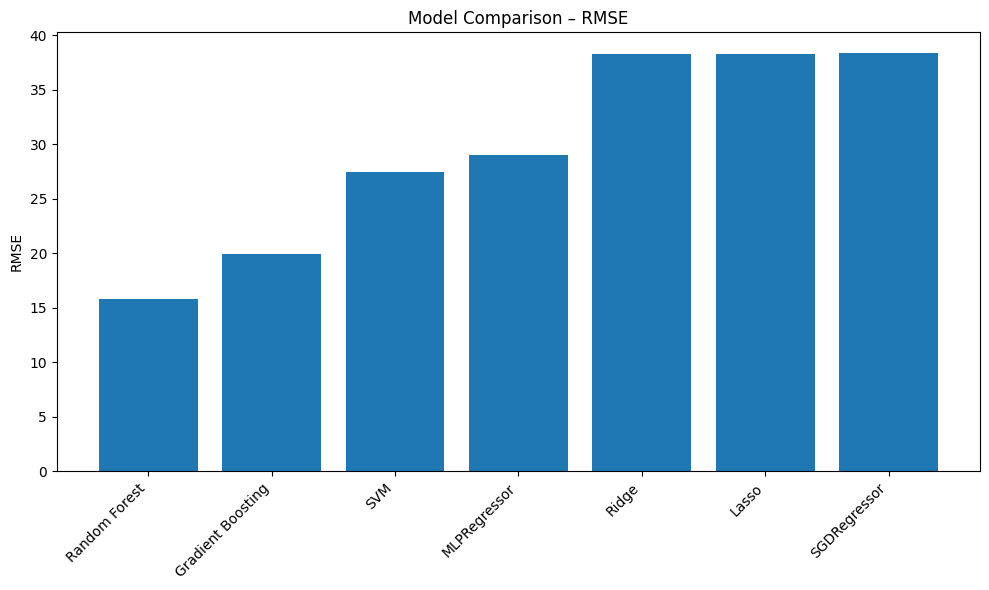

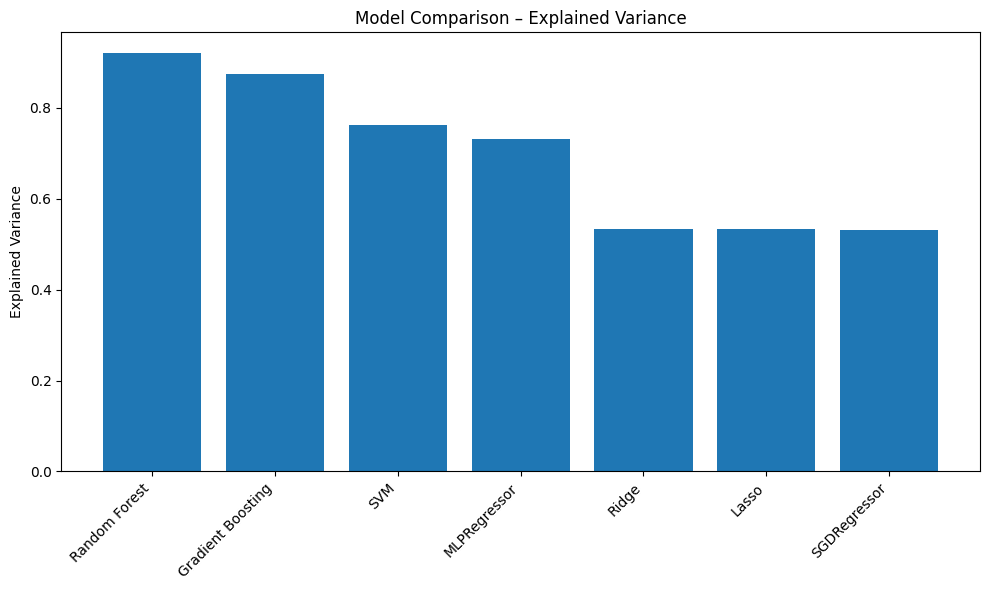

In [38]:
#final models
finalPipeRF = Pipeline([('featureSelect', SelectPercentile(percentile=bestRfPerc)), ('rgr', RandomForestRegressor(**bestParamsRF))])
finalPipeGB = Pipeline([('featureSelect', SelectPercentile(percentile=bestGbPerc)), ('rgr', GradientBoostingRegressor(**bestParamsGB))])
finalPipeSVM = Pipeline([('featureSelect', SelectPercentile(percentile=bestSvmPerc)), ('rgr', SVR(**bestParamsSVM))])
finalPipeRidge = Pipeline([('featureSelect', SelectPercentile(percentile=bestRidgePerc)), ('rgr', Ridge(alpha = bestRidgeAlpha))])
finalPipeLasso = Pipeline([('featureSelect', SelectPercentile(percentile=bestLassoPerc)), ('rgr', Lasso(alpha = bestLassoAlpha))])
finalPipeSGD = Pipeline([('featureSelect', SelectPercentile(percentile=bestSgdPerc)), ('rgr', SGDRegressor(**bestParamsSGD))])
finalPipeMLP = Pipeline([('featureSelect', SelectPercentile(percentile=bestSvmPerc)), ('rgr', MLPRegressor(**bestParamsMLP))])


finalModels = {
    "Random Forest": finalPipeRF,
    "Gradient Boosting": finalPipeGB,
    "SVM": finalPipeSVM,
    "Ridge": finalPipeRidge,
    "Lasso": finalPipeLasso,
    "SGDRegressor": finalPipeSGD,
    "MLPRegressor": finalPipeMLP
}

scorers = {'Neg_MSE': 'neg_mean_squared_error','expl_var': 'explained_variance'}


results = []

for modelName, pipe in finalModels.items():
    print(f"\n===== Evaluating: {modelName} =====")

    start_ts = time.time()
    scores = cross_validate(pipe, X_test_scaled, y_test, scoring=scorers, cv=5)

    rmseScores = np.asarray([math.sqrt(-v) for v in scores["test_Neg_MSE"]])
    ev_scores  = scores["test_expl_var"]

    results.append({
        "Model": modelName,
        "Mean_RMSE": rmseScores.mean(),
        "Std_RMSE": rmseScores.std() * 2,
        "Mean_Expl_Var": ev_scores.mean(),
        "Std_Expl_Var": ev_scores.std() * 2,
        "Runtime_sec": time.time() - start_ts
    })

    print(f"{modelName} RMSE: {rmseScores.mean():.3f} (+/- {rmseScores.std()*2:.3f})")
    print(f"{modelName} Explained Var: {ev_scores.mean():.3f} (+/- {ev_scores.std()*2:.3f})")
    print(f"{modelName} Runtime: {time.time()-start_ts:.2f} sec")



results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Mean_RMSE")

print("\n================ Final Model Comparison Table ================\n")
print(results_df.to_string(index=False))

#RMSE bar plot
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Mean_RMSE"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("RMSE")
plt.title("Model Comparison – RMSE")
plt.tight_layout()
plt.show()

#expl var bar plot
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Mean_Expl_Var"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Explained Variance")
plt.title("Model Comparison – Explained Variance")
plt.tight_layout()
plt.show()